In [1]:
# Upgrade to newer versions that support numpy 2.x
!pip install -q --upgrade librosa soundfile gradio

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 17.3 MB/s eta 0:00:00
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 1 - imports & reproducibility
import os, random, math, glob, itertools, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
# Cell 2 - Mount Drive and check files in ADHD_project folder
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/ADHD_project/data"  # change if your folder path differs
adhd_dir = os.path.join(BASE_DIR, "ADHD")
ctrl_dir = os.path.join(BASE_DIR, "Control")

print("Base dir:", BASE_DIR)
print("ADHD dir exists:", os.path.exists(adhd_dir))
print("Control dir exists:", os.path.exists(ctrl_dir))

def list_mat_files(path):
    return sorted(glob.glob(os.path.join(path, "*.mat")))

adhd_files = list_mat_files(adhd_dir) if os.path.exists(adhd_dir) else []
ctrl_files = list_mat_files(ctrl_dir) if os.path.exists(ctrl_dir) else []

print(f"Found {len(adhd_files)} ADHD .mat files, {len(ctrl_files)} Control .mat files.")
# List a few
print("Sample ADHD files:", adhd_files[:5])
print("Sample Control files:", ctrl_files[:5])

# Basic check: expected counts
if len(adhd_files) != 61 or len(ctrl_files) != 60:
    print("WARNING: file counts differ from expected (61 ADHD & 60 Control). Please verify.")


Mounted at /content/drive
Base dir: /content/drive/MyDrive/ADHD_project/data
ADHD dir exists: True
Control dir exists: True
Found 61 ADHD .mat files, 60 Control .mat files.
Sample ADHD files: ['/content/drive/MyDrive/ADHD_project/data/ADHD/v10p.mat', '/content/drive/MyDrive/ADHD_project/data/ADHD/v12p.mat', '/content/drive/MyDrive/ADHD_project/data/ADHD/v14p.mat', '/content/drive/MyDrive/ADHD_project/data/ADHD/v15p.mat', '/content/drive/MyDrive/ADHD_project/data/ADHD/v173.mat']
Sample Control files: ['/content/drive/MyDrive/ADHD_project/data/Control/v107.mat', '/content/drive/MyDrive/ADHD_project/data/Control/v108.mat', '/content/drive/MyDrive/ADHD_project/data/Control/v109.mat', '/content/drive/MyDrive/ADHD_project/data/Control/v110.mat', '/content/drive/MyDrive/ADHD_project/data/Control/v111.mat']


In [4]:
# Cell 3 - parameters (edit these for experiments)
SR = 128                   # sampling rate (Hz)
SEGMENT_LEN = 512          # samples per segment (4s @128Hz)
SEGMENT_HOP = SEGMENT_LEN // 2  # 50% overlap
N_MELS = 64                # mel bands (you requested 64)
N_FFT = 512
HOP_LENGTH = 128
SPEC_SIZE = (128, 128)     # final spectrogram image size (H, W)
BATCH_SIZE = 16
EPOCHS = 80
LEARNING_RATE = 3e-4
PATCH_SIZE = 16            # patch size for ViT
NUM_CLASSES = 2
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "vit_eeg_ad_hd_model.h5")
AUTOTUNE = tf.data.AUTOTUNE


In [5]:
# Cell 4 - loader: robust .mat loader
def load_mat_eeg(path):
    """
    Attempt to load EEG array from a .mat file.
    Returns (data: np.ndarray shape (n_channels, n_samples), sr)
    """
    mat = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
    # Inspect common keys
    # If file directly contains array, try to find it
    candidate = None
    for k,v in mat.items():
        if k.startswith("__"):
            continue
        # if v is ndarray of floats/ints choose it
        if isinstance(v, np.ndarray) and v.ndim >= 1 and np.issubdtype(v.dtype, np.number):
            candidate = v
            break
        # sometimes inside dict-like struct
        if hasattr(v, "__dict__") or (isinstance(v, dict)):
            # try to find numeric ndarray inside
            for kk,vv in (v.items() if isinstance(v, dict) else v.__dict__.items()):
                if isinstance(vv, np.ndarray) and np.issubdtype(vv.dtype, np.number):
                    candidate = vv
                    break
    if candidate is None:
        # print keys to help debug
        print(f"Could not auto-extract numeric array from {path}. Keys:", [k for k in mat.keys() if not k.startswith("__")])
        raise ValueError("No numeric array found in .mat file. Inspect manually.")
    arr = np.array(candidate)
    # Ensure shape (n_channels, n_samples)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]  # single channel
    if arr.shape[0] < arr.shape[1]:
        # assume shape (n_channels, n_samples) is correct if channels < samples
        pass
    else:
        # sometimes shape is (n_samples, n_channels) — we prefer (n_channels, n_samples)
        if arr.shape[0] > arr.shape[1]:
            arr = arr.T
    return arr.astype(np.float32)

# quick test on sample file if exists
if len(adhd_files) > 0:
    sample_arr = load_mat_eeg(adhd_files[0])
    print("Sample shape (channels, samples):", sample_arr.shape)


Sample shape (channels, samples): (19, 14304)


Spectrogram shape: (128, 128, 1) label: 1


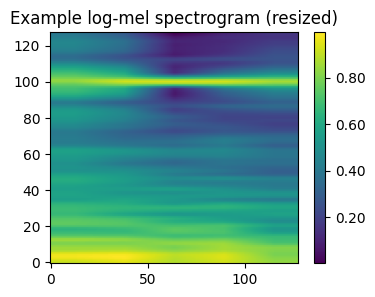

In [6]:
# Cell 5 - preprocessing: segmentation, normalization, mel spectrogram
import tensorflow as tf
def zscore(x, axis=None, eps=1e-8):
    mu = x.mean(axis=axis, keepdims=True)
    sd = x.std(axis=axis, keepdims=True)
    return (x - mu) / (sd + eps)

def seg_generator_from_matpath(path, label, channels_to_use=None,
                               add_noise_prob=0.0, noise_std=0.003):
    """
    Generator yields (spectrogram_image, label)
    """
    arr = load_mat_eeg(path)  # shape (n_channels, n_samples)
    # select channel(s): you can average over channels or pick specific channel(s).
    # We'll average over all channels (common approach). For more complexity, you can handle per-channel models.
    data = arr.mean(axis=0)  # 1D
    n = data.shape[0]
    i = 0
    while i + SEGMENT_LEN <= n:
        seg = data[i:i+SEGMENT_LEN].astype(np.float32)
        # augmentation: noise with probability
        if add_noise_prob > 0 and random.random() < add_noise_prob:
            seg = seg + np.random.normal(0, noise_std, seg.shape).astype(np.float32)
        # zscore
        seg = zscore(seg)
        # mel spectrogram (librosa)
        S = librosa.feature.melspectrogram(y=seg, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0)
        S_db = librosa.power_to_db(S, ref=np.max)
        # normalize to 0-1
        S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
        # resize to SPEC_SIZE
        S_resized = tf.image.resize(S_norm[..., np.newaxis], SPEC_SIZE).numpy()
        yield S_resized.astype(np.float32), np.int32(label)
        i += SEGMENT_HOP

# quick visualization for one segment
if len(adhd_files)>0:
    seg_gen = seg_generator_from_matpath(adhd_files[0], 1)
    s, lab = next(seg_gen)
    print("Spectrogram shape:", s.shape, "label:", lab)
    plt.figure(figsize=(4,3))
    plt.title("Example log-mel spectrogram (resized)")
    plt.imshow(s[:,:,0], aspect='auto', origin='lower')
    plt.colorbar(format='%0.2f')
    plt.show()


In [7]:
# Cell 6 - assemble list of sample entries (one entry per segmented window)
entries = []
for p in adhd_files:
    entries.append((p, 1))
for p in ctrl_files:
    entries.append((p, 0))
print("Total subject files:", len(entries))
# We'll create tf.data from generator per-file to avoid huge memory use

# Quick class balance at subject-level
labels = [lab for (_,lab) in entries]
print("Subjects per class:", {0: labels.count(0), 1: labels.count(1)})


Total subject files: 121
Subjects per class: {0: 60, 1: 61}


In [17]:
# Cell 7 (REPLACE existing dataset creation) - fixed-size tf.data pipeline
def make_dataset_fixed(entries, shuffle=True, augment=False):
    def gen():
        for path, label in entries:
            for img, lab in seg_generator_from_matpath(path, label, add_noise_prob=0.2 if augment else 0.0):
                yield img.astype(np.float32), np.int32(lab)
    ds = tf.data.Dataset.from_generator(gen, output_signature=(
        tf.TensorSpec(shape=SPEC_SIZE + (1,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)  # <-- fixed-size batches
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Re-create splits/datasets (uses train_subj, val_subj, test_subj from earlier)
train_ds = make_dataset_fixed(train_subj, shuffle=True, augment=True)
val_ds   = make_dataset_fixed(val_subj, shuffle=False, augment=False)
test_ds  = make_dataset_fixed(test_subj, shuffle=False, augment=False)

# Diagnostic: inspect one batch and run through model to check shapes
for xb, yb in train_ds.take(1):
    print("X batch shape:", xb.shape, "dtype:", xb.dtype)
    print("y batch shape:", yb.shape, "dtype:", yb.dtype)
    preds = vit(xb, training=False)
    print("Model raw output shape:", preds.shape, "dtype:", preds.dtype)
    break


X batch shape: (16, 128, 128, 1) dtype: <dtype: 'float32'>
y batch shape: (16,) dtype: <dtype: 'int32'>
Model raw output shape: (16, 2) dtype: <dtype: 'float32'>


In [18]:
# Cell 8 - ViT implementation (Keras) — fixed (wrap cls & pos-emb in a Layer)
from tensorflow.keras.layers import Layer

class PatchEncoder(Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        # we'll create conv in build because we need input shape sometimes
        self.proj = layers.Conv2D(filters=embed_dim, kernel_size=patch_size, strides=patch_size, padding='valid')
        self.reshape = layers.Reshape((-1, embed_dim))

    def build(self, input_shape):
        # input_shape: (batch, H, W, C)
        H = input_shape[1]
        W = input_shape[2]
        patches_h = H // self.patch_size
        patches_w = W // self.patch_size
        self.num_patches = int(patches_h * patches_w)
        # CLS token as a trainable weight
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True,
            name="cls_token"
        )
        # positional embedding for (num_patches + 1)
        self.pos_emb = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            name="pos_embedding"
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, H, W, C)
        x = self.proj(inputs)  # (batch, H/ps, W/ps, embed_dim)
        x = self.reshape(x)    # (batch, num_patches, embed_dim)
        batch_size = tf.shape(x)[0]
        cls_b = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls_b, x], axis=1)  # (batch, num_patches+1, embed_dim)
        x = x + self.pos_emb  # positional embeddings broadcast across batch
        return x

def create_vit_classifier(input_shape=(128,128,1),
                          patch_size=16,
                          embed_dim=256,
                          num_heads=8,
                          mlp_dim=512,
                          transformer_layers=8,
                          dropout_rate=0.1,
                          num_classes=2):
    inputs = layers.Input(shape=input_shape)
    # Patchify + CLS + PosEmb (all inside custom layer)
    x = PatchEncoder(patch_size=patch_size, embed_dim=embed_dim)(inputs)  # (batch, num_patches+1, embed_dim)

    # Transformer encoder blocks
    for i in range(transformer_layers):
        # Pre-norm
        x1 = layers.LayerNormalization(epsilon=1e-6, name=f"ln1_{i}")(x)
        attn_out = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim // num_heads,
                                             dropout=dropout_rate,
                                             name=f"mha_{i}")(x1, x1)
        x = layers.Add(name=f"res1_{i}")([x, attn_out])

        x2 = layers.LayerNormalization(epsilon=1e-6, name=f"ln2_{i}")(x)
        mlp = layers.Dense(mlp_dim, activation=layers.LeakyReLU(0.2), name=f"mlp_fc1_{i}")(x2)
        mlp = layers.Dropout(dropout_rate, name=f"mlp_drop_{i}")(mlp)
        mlp = layers.Dense(embed_dim, name=f"mlp_fc2_{i}")(mlp)
        x = layers.Add(name=f"res2_{i}")([x, mlp])

    x = layers.LayerNormalization(epsilon=1e-6, name="encoder_ln")(x)
    # Extract CLS token (first token)
    cls_token = layers.Lambda(lambda z: z[:, 0, :], name="extract_cls")(x)  # (batch, embed_dim)

    out = layers.Dense(128, activation=layers.LeakyReLU(0.2), name="head_fc1")(cls_token)
    out = layers.Dropout(0.2, name="head_drop")(out)
    logits = layers.Dense(num_classes, activation='softmax', name="head_logits")(out)

    model = keras.Model(inputs=inputs, outputs=logits, name="ViT_EEG")
    return model

# instantiate
vit = create_vit_classifier(input_shape=SPEC_SIZE+(1,), patch_size=PATCH_SIZE,
                            embed_dim=256, num_heads=8, mlp_dim=512, transformer_layers=8,
                            num_classes=NUM_CLASSES)
vit.summary()


Model: "ViT_EEG"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 65, 256)   │     82,688 │ input_layer_3[0]… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_0               │ (None, 65, 256)   │        512 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_0               │ (None, 65, 256)   │    263,168 │ ln1_0[0][0],      │
│ (MultiHeadAttentio… │                   │            │ ln1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_0 (Add)        │ (None, 65, 256)   │          0 │ patch_encoder_2[… │
│                     │                   │            │ mha_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2_0               │ (None, 65, 256)   │        512 │ res1_0[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_fc1_0 (Dense)   │ (None, 65, 512)   │    131,584 │ ln2_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_0          │ (None, 65, 512)   │          0 │ mlp_fc1_0[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_fc2_0 (Dense)   │ (None, 65, 256)   │    131,328 │ mlp_drop_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_0 (Add)        │ (None, 65, 256)   │          0 │ res1_0[0][0],     │
│                     │                   │            │ mlp_fc2_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_1               │ (None, 65, 256)   │        512 │ res2_0[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 65, 256)   │    263,168 │ ln1_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ ln1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_1 (Add)        │ (None, 65, 256)   │          0 │ res2_0[0][0],     │
│                     │                   │            │ mha_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2_1               │ (None, 65, 256)   │        512 │ res1_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_fc1_1 (Dense)   │ (None, 65, 512)   │    131,584 │ ln2_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_1          │ (None, 65, 512)   │          0 │ mlp_fc1_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_fc2_1 (Dense)   │ (None, 65, 256)   │    131,328 │ mlp_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_1 (Add)        │ (None, 65, 256)   │          0 │ res1_1[0][0],     │
│                     │                   │            │ mlp_fc2_1[0][0] 

 Total params: 4,333,186 (16.53 MB)

 Trainable params: 4,333,186 (16.53 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Cell 9 - compile & callbacks (safe)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Compile WITHOUT built-in Keras metrics to avoid the UnsortedSegmentSum metric codepath
vit.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=[])

# Callbacks: monitor val_loss (always present)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', mode='min', save_best_only=True, verbose=1)
]

# Optional: enable eager for a readable Python traceback (very slow). Uncomment only if we need to debug further.
# vit.run_eagerly = True

print("Compiled. run_eagerly =", getattr(vit, "run_eagerly", False))


Compiled. run_eagerly = False


In [20]:
# Cell 10 - training (safe)
history = vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save final
vit.save(MODEL_SAVE_PATH)
print("Model saved to", MODEL_SAVE_PATH)


Epoch 1/80
    390/Unknown 116s 175ms/step - loss: 0.8143

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 0.70094, saving model to /content/drive/MyDrive/ADHD_project/data/vit_eeg_ad_hd_model.h5


390/390 ━━━━━━━━━━━━━━━━━━━━ 133s 219ms/step - loss: 0.8141 - val_loss: 0.7009 - learning_rate: 3.0000e-04
Epoch 2/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.6796
Epoch 2: val_loss improved from 0.70094 to 0.68191, saving model to /content/drive/MyDrive/ADHD_project/data/vit_eeg_ad_hd_model.h5


390/390 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - loss: 0.6797 - val_loss: 0.6819 - learning_rate: 3.0000e-04
Epoch 3/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.6828
Epoch 3: val_loss improved from 0.68191 to 0.66191, saving model to /content/drive/MyDrive/ADHD_project/data/vit_eeg_ad_hd_model.h5


...

390/390 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - loss: 0.5336 - val_loss: 0.2999 - learning_rate: 3.0000e-04
Epoch 11/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.4893
Epoch 11: val_loss did not improve from 0.29990
390/390 ━━━━━━━━━━━━━━━━━━━━ 36s 75ms/step - loss: 0.4893 - val_loss: 0.3874 - learning_rate: 3.0000e-04
Epoch 12/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4612
Epoch 12: val_loss did not improve from 0.29990
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - loss: 0.4612 - val_loss: 0.3472 - learning_rate: 3.0000e-04
Epoch 13/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.4959
Epoch 13: val_loss did not improve from 0.29990
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - loss: 0.4961 - val_loss: 0.3817 - learning_rate: 3.0000e-04
Epoch 14/80
388/390 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.6183
Epoch 14: val_loss did not improve from 0.29990
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - loss: 0.6185 - val_loss: 0.4835 - learning_rate: 3.0000e-04
Epoch 1

390/390 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - loss: 0.4986 - val_loss: 0.2509 - learning_rate: 1.5000e-04
Epoch 17/80
388/390 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.4725
Epoch 17: val_loss improved from 0.25088 to 0.22598, saving model to /content/drive/MyDrive/ADHD_project/data/vit_eeg_ad_hd_model.h5


390/390 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - loss: 0.4724 - val_loss: 0.2260 - learning_rate: 1.5000e-04
Epoch 18/80
388/390 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.4569
Epoch 18: val_loss did not improve from 0.22598
390/390 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - loss: 0.4567 - val_loss: 0.3477 - learning_rate: 1.5000e-04
Epoch 19/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4776
Epoch 19: val_loss did not improve from 0.22598
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - loss: 0.4774 - val_loss: 0.3452 - learning_rate: 1.5000e-04
Epoch 20/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4948
Epoch 20: val_loss did not improve from 0.22598
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - loss: 0.4948 - val_loss: 0.2896 - learning_rate: 1.5000e-04
Epoch 21/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4610
Epoch 21: val_loss did not improve from 0.22598
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - loss: 0.4609 - val_loss: 0.3052 - learning_rate: 1.5000e-04
Epoch 2

390/390 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - loss: 0.4178 - val_loss: 0.2231 - learning_rate: 7.5000e-05
Epoch 28/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.4245
Epoch 28: val_loss did not improve from 0.22313
390/390 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - loss: 0.4243 - val_loss: 0.3069 - learning_rate: 7.5000e-05
Epoch 29/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.4120
Epoch 29: val_loss did not improve from 0.22313
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - loss: 0.4119 - val_loss: 0.2465 - learning_rate: 7.5000e-05
Epoch 30/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.4157
Epoch 30: val_loss did not improve from 0.22313
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - loss: 0.4156 - val_loss: 0.2661 - learning_rate: 7.5000e-05
Epoch 31/80
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4050
Epoch 31: val_loss did not improve from 0.22313
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - loss: 0.4049 - val_loss: 0.2873 - learning_rate: 7.5000e-05
Epoch 3

Model saved to /content/drive/MyDrive/ADHD_project/data/vit_eeg_ad_hd_model.h5


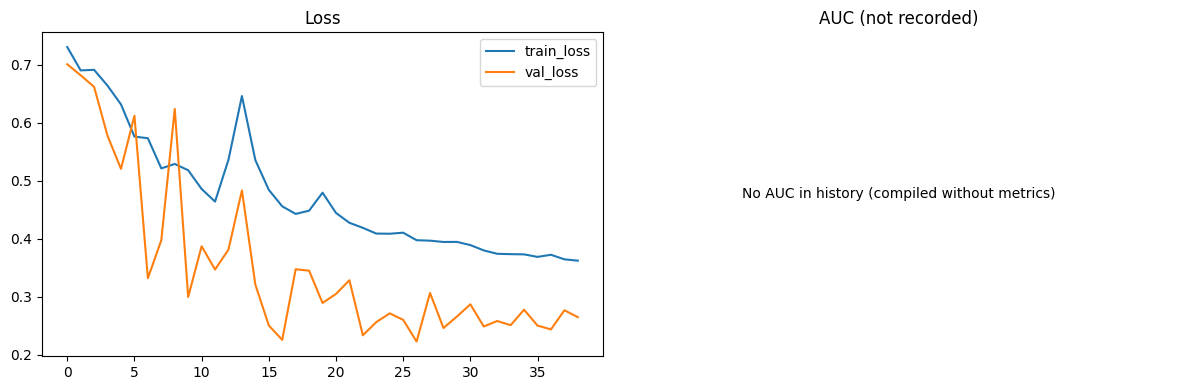

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━

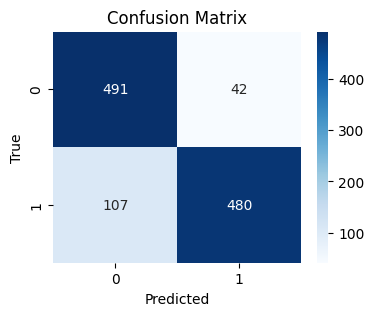

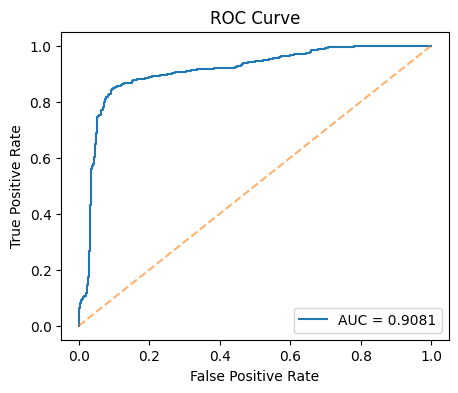

Saved test predictions to: /content/drive/MyDrive/ADHD_project/data/test_predictions.csv


In [22]:
# Cell 11 - safe plot & evaluate (replacement)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score

# 1) Safe plotting of training history
def safe_plot_history(history):
    if history is None:
        print("No history object found.")
        return
    keys = list(history.history.keys())
    plt.figure(figsize=(12,4))
    # Loss subplot (always expected)
    plt.subplot(1,2,1)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='train_loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')

    # AUC subplot if present
    plt.subplot(1,2,2)
    auc_present = False
    if 'auc' in history.history:
        plt.plot(history.history['auc'], label='train_auc'); auc_present = True
    if 'val_auc' in history.history:
        plt.plot(history.history['val_auc'], label='val_auc'); auc_present = True
    if auc_present:
        plt.legend(); plt.title('AUC')
    else:
        plt.text(0.5, 0.5, 'No AUC in history (compiled without metrics)', ha='center', va='center')
        plt.title('AUC (not recorded)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

safe_plot_history(history)

# 2) Evaluate on test set (collect predictions & labels)
y_true = []
y_pred = []
y_proba = []
for xb, yb in test_ds:
    preds = vit.predict(xb)
    y_proba.extend(preds[:,1].tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

# Basic checks
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

print(f"Total test samples: {len(y_true)}")
# 3) Metrics
try:
    test_auc = roc_auc_score(y_true, y_proba)
except Exception as e:
    test_auc = None
    print("Could not compute AUC:", e)

test_f1 = f1_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)

print("\n=== Test set metrics ===")
if test_auc is not None:
    print(f"AUC   : {test_auc:.4f}")
else:
    print("AUC   : n/a")
print(f"F1    : {test_f1:.4f}")
print(f"Prec  : {test_precision:.4f}")
print(f"Recall : {test_recall:.4f}")
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, digits=4))

# 4) Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

# 5) ROC curve plot (if auc available)
if test_auc is not None:
    fpr, tpr, th = roc_curve(y_true, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_val:.4f}')
    plt.plot([0,1],[0,1], linestyle='--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
else:
    print("ROC curve skipped (AUC not available).")

# 6) Save predictions (optional) to Drive for later analysis
import pandas as pd
out_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "y_proba": y_proba})
out_csv = os.path.join(BASE_DIR, "test_predictions.csv")
out_df.to_csv(out_csv, index=False)
print("Saved test predictions to:", out_csv)


Found MHA layers: 8
Using patch encoder layer: patch_encoder_2
True label: 1


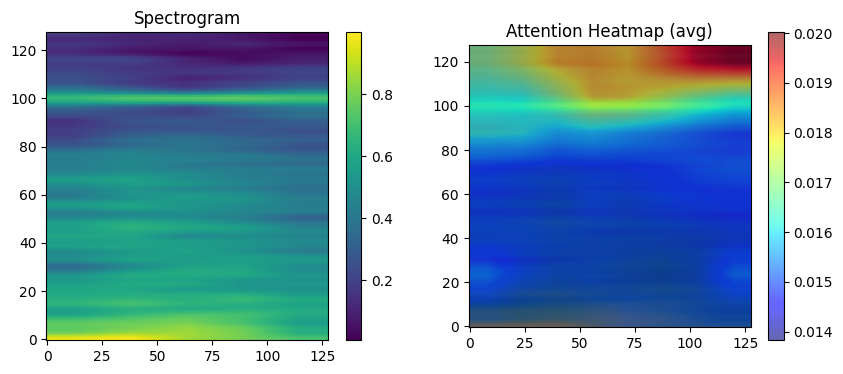

In [24]:
# Cell 12 - attention extraction & visualization (fixed for PatchEncoder)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Find MHA layers
mha_layers = [layer for layer in vit.layers if isinstance(layer, tf.keras.layers.MultiHeadAttention)]
print("Found MHA layers:", len(mha_layers))

# Find the PatchEncoder-like layer (has attribute 'proj')
patch_encoder_layer = None
for layer in vit.layers:
    if hasattr(layer, "proj") and hasattr(layer, "pos_emb"):
        patch_encoder_layer = layer
        break
# fallback: find any layer with attribute 'proj'
if patch_encoder_layer is None:
    for layer in vit.layers:
        if hasattr(layer, "proj"):
            patch_encoder_layer = layer
            break

if patch_encoder_layer is None:
    raise RuntimeError("Could not find the PatchEncoder layer. Inspect model.layers for correct layer.")

print("Using patch encoder layer:", patch_encoder_layer.name)

def show_attention_on_spectrogram(model, image):
    """
    image: numpy array shape (H, W, 1)
    """
    # prepare tensor
    img_tf = tf.convert_to_tensor(np.expand_dims(image, axis=0), dtype=tf.float32)  # (1,H,W,1)
    # get token embeddings from PatchEncoder (includes CLS + pos embedding)
    tokens = patch_encoder_layer(img_tf)  # (1, seq_len, embed_dim) where seq_len = num_patches+1
    # find the last MHA layer in the model
    last_mha = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            last_mha = layer
            break
    if last_mha is None:
        print("No MultiHeadAttention layer found.")
        return
    # call last_mha to get attention scores
    try:
        # return_attention_scores=True supported in TF >=2.9 MultiHeadAttention
        attn_out, attn_scores = last_mha(tokens, tokens, return_attention_scores=True)
    except Exception as e:
        print("Could not get attention scores from last_mha:", e)
        return
    # attn_scores shape: (batch, num_heads, seq_len_q, seq_len_k)
    attn_scores = attn_scores.numpy()  # convert to numpy
    # average across heads and queries to get per-key importance (or other summary)
    # We'll average across heads and queries to get an attention weight per key token
    avg_heads = np.mean(attn_scores, axis=1)  # (batch, seq_len_q, seq_len_k)
    # average queries dimension to see how much each key was attended to overall
    attn_to_each_token = np.mean(avg_heads[0], axis=0)  # (seq_len_k,)
    # remove CLS token (first token) to map back to patches
    attn_patches = attn_to_each_token[1:]  # shape (num_patches,)
    num_patches = attn_patches.shape[0]
    side = int(np.sqrt(num_patches))
    if side * side != num_patches:
        # fallback: try to infer side from patch encoder's attribute if available
        try:
            num_patches = patch_encoder_layer.num_patches
            side = int(np.sqrt(num_patches))
        except:
            raise RuntimeError(f"num_patches {num_patches} is not a perfect square; cannot reshape.")
    heat = attn_patches.reshape(side, side)  # (side, side)
    # resize heat to spectrogram dims
    heat_img = tf.image.resize(heat[..., np.newaxis], SPEC_SIZE).numpy()[:,:,0]
    # Plot spectrogram and overlay heatmap
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Spectrogram")
    plt.imshow(image[:,:,0], origin='lower', aspect='auto')
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.title("Attention Heatmap (avg)")
    plt.imshow(image[:,:,0], origin='lower', aspect='auto')
    plt.imshow(heat_img, origin='lower', alpha=0.6, cmap='jet')
    plt.colorbar()
    plt.show()

# pick one sample from test_ds
for xb, yb in test_ds.take(1):
    sample_img = xb[0].numpy()
    sample_label = int(yb[0].numpy())
    break

print("True label:", sample_label)
show_attention_on_spectrogram(vit, sample_img)


In [29]:
# Cell A - load model safely and provide helpers (run once)
import os, tempfile, numpy as np, librosa, scipy.io, tensorflow as tf, pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

# --- settings (ensure these match your notebook) ---
BASE_DIR = "/content/drive/MyDrive/ADHD_project"  # or change if different
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "vit_eeg_ad_hd_model.h5")  # same as before
SR = 128
SEGMENT_LEN = 512
SEGMENT_HOP = SEGMENT_LEN // 2
N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64
SPEC_SIZE = (128, 128)

# --- re-declare PatchEncoder (must match the saved model) ---
from tensorflow.keras.layers import Layer
class PatchEncoder(Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(filters=embed_dim, kernel_size=patch_size, strides=patch_size, padding='valid')
        self.reshape = layers.Reshape((-1, embed_dim))
    def build(self, input_shape):
        H = input_shape[1]; W = input_shape[2]
        patches_h = H // self.patch_size; patches_w = W // self.patch_size
        self.num_patches = int(patches_h * patches_w)
        self.cls_token = self.add_weight(shape=(1,1,self.embed_dim), initializer="zeros", trainable=True, name="cls_token")
        self.pos_emb = self.add_weight(shape=(1,self.num_patches+1,self.embed_dim),
                                       initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
                                       trainable=True, name="pos_embedding")
        super().build(input_shape)
    def call(self, inputs):
        x = self.proj(inputs)
        x = self.reshape(x)
        batch_size = tf.shape(x)[0]
        cls_b = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls_b, x], axis=1)
        x = x + self.pos_emb
        return x

# Attempt to reuse model if loaded, otherwise load from disk
try:
    model  # if exists
    print("Model already in memory.")
except NameError:
    print("Loading model from disk:", MODEL_SAVE_PATH)
    try:
        model = tf.keras.models.load_model(MODEL_SAVE_PATH, custom_objects={"PatchEncoder": PatchEncoder})
        print("Model loaded via load_model.")
    except Exception as e:
        print("load_model failed:", e)
        # fallback: try recreate architecture and load weights
        # NOTE: ensure create_vit_classifier is defined in notebook (from earlier cells)
        try:
            model = create_vit_classifier(input_shape=SPEC_SIZE+(1,), patch_size=16,
                                          embed_dim=256, num_heads=8, mlp_dim=512, transformer_layers=8,
                                          num_classes=2)
            model.load_weights(MODEL_SAVE_PATH)
            print("Weights loaded into recreated architecture.")
        except Exception as e2:
            raise RuntimeError("Failed to load model or weights. Inspect MODEL_SAVE_PATH and model code.") from e2

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')  # compile for predict (metrics optional)
print("Model ready.")

# --- helper: robust .mat loader ---
def load_mat_eeg(path):
    mat = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
    candidate = None
    for k,v in mat.items():
        if k.startswith("__"): continue
        if isinstance(v, np.ndarray) and v.ndim >= 1 and np.issubdtype(v.dtype, np.number):
            candidate = v; break
        if isinstance(v, dict):
            for kk,vv in v.items():
                if isinstance(vv, np.ndarray) and np.issubdtype(vv.dtype, np.number):
                    candidate = vv; break
    if candidate is None:
        # show keys for debugging
        print("Could not auto-find numeric array inside .mat. Keys:", [k for k in mat.keys() if not k.startswith("__")])
        raise ValueError("No numeric array found in .mat.")
    arr = np.array(candidate).astype(np.float32)
    # ensure shape (n_channels, n_samples)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]
    if arr.shape[0] > arr.shape[1]:
        arr = arr.T
    return arr

# --- helper: zscore ---
def zscore(x, eps=1e-8):
    mu = np.mean(x)
    sd = np.std(x)
    return (x - mu) / (sd + eps)

# --- helper: get segments and spectrograms from path ---
def segments_from_mat(path, segment_len=SEGMENT_LEN, hop=SEGMENT_HOP, sr=SR, n_mels=N_MELS):
    arr = load_mat_eeg(path)  # (ch, samples)
    data = arr.mean(axis=0)   # average channels
    n = data.shape[0]
    segs = []
    i = 0
    while i + segment_len <= n:
        seg = data[i:i+segment_len].astype(np.float32)
        seg = zscore(seg)
        S = librosa.feature.melspectrogram(y=seg, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=n_mels, power=2.0)
        S_db = librosa.power_to_db(S, ref=np.max)
        S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
        S_resized = tf.image.resize(S_norm[..., np.newaxis], SPEC_SIZE).numpy().astype(np.float32)
        segs.append(S_resized)
        i += hop
    return segs


Model already in memory.
Model ready.


In [31]:
# Cell B - upload .mat (Colab) and predict (run this cell)
from google.colab import files
import numpy as np
import os
import pandas as pd
from sklearn.metrics import roc_auc_score

uploaded = files.upload()  # dialog — upload one or more .mat files

for fname, content in uploaded.items():
    print("Processing:", fname)
    # write bytes to temp file
    tmp_path = os.path.join("/tmp", fname)
    with open(tmp_path, "wb") as f:
        f.write(content)
    # get spectrogram segments
    segs = segments_from_mat(tmp_path)
    if len(segs) == 0:
        print("No segments found (file too short). Skipping.")
        continue

    probs = []
    preds = []
    for s in segs:
        p = model.predict(np.expand_dims(s, axis=0))[0]  # softmax output [prob_control, prob_adhd]
        probs.append(float(p[1]))
        preds.append(int(np.argmax(p)))

    avg_prob = float(np.mean(probs))
    majority = int(round(np.mean(preds)))  # 1 if more ADHD segments than control on average
    label_str = "ADHD" if avg_prob > 0.5 else "Control"

    print(f"Segments analyzed: {len(segs)}")
    print(f"Average ADHD probability across segments: {avg_prob:.4f}")
    print(f"Majority segments prediction: {'ADHD' if majority==1 else 'Control'}")
    print(f"Final decision (threshold 0.5 on avg prob): {label_str}")

    # save per-segment probabilities
    df = pd.DataFrame({"segment_index": list(range(len(segs))), "adhd_prob": probs, "pred": preds})
    out_csv = os.path.join(BASE_DIR, f"predictions_{os.path.splitext(fname)[0]}.csv")
    df.to_csv(out_csv, index=False)
    print("Saved per-segment predictions to:", out_csv)


Saving v24p.mat to v24p.mat
Processing: v24p.mat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1